# 다양한 앙상블 원리

## 배깅 (Bagging)
- 여러 개의 “서로 다른” 모델을 만들고 평균내면 분산이 줄어든다.

  - 원본 데이터에서 복원추출(bootstrap) 로 여러 데이터셋 생성

  - 각각 독립적으로 모델 학습

  - 결과를 평균(회귀) 또는 다수결(분류)
- Random Forest

## 부스팅 (Boosting)
- 이전 모델의 오차를 다음 모델이 보완한다.

  - 첫 모델 생성

  - 오차 계산

  - 오차를 예측하는 모델 생성

  - 반복
- XGB (Level-wise : 균형적으로 오차 보완)
- Light GBM (Leaf-wise : leaf에 집중해서 오차 보완)
- Cat Boost (범주형 변수 처리 능력)


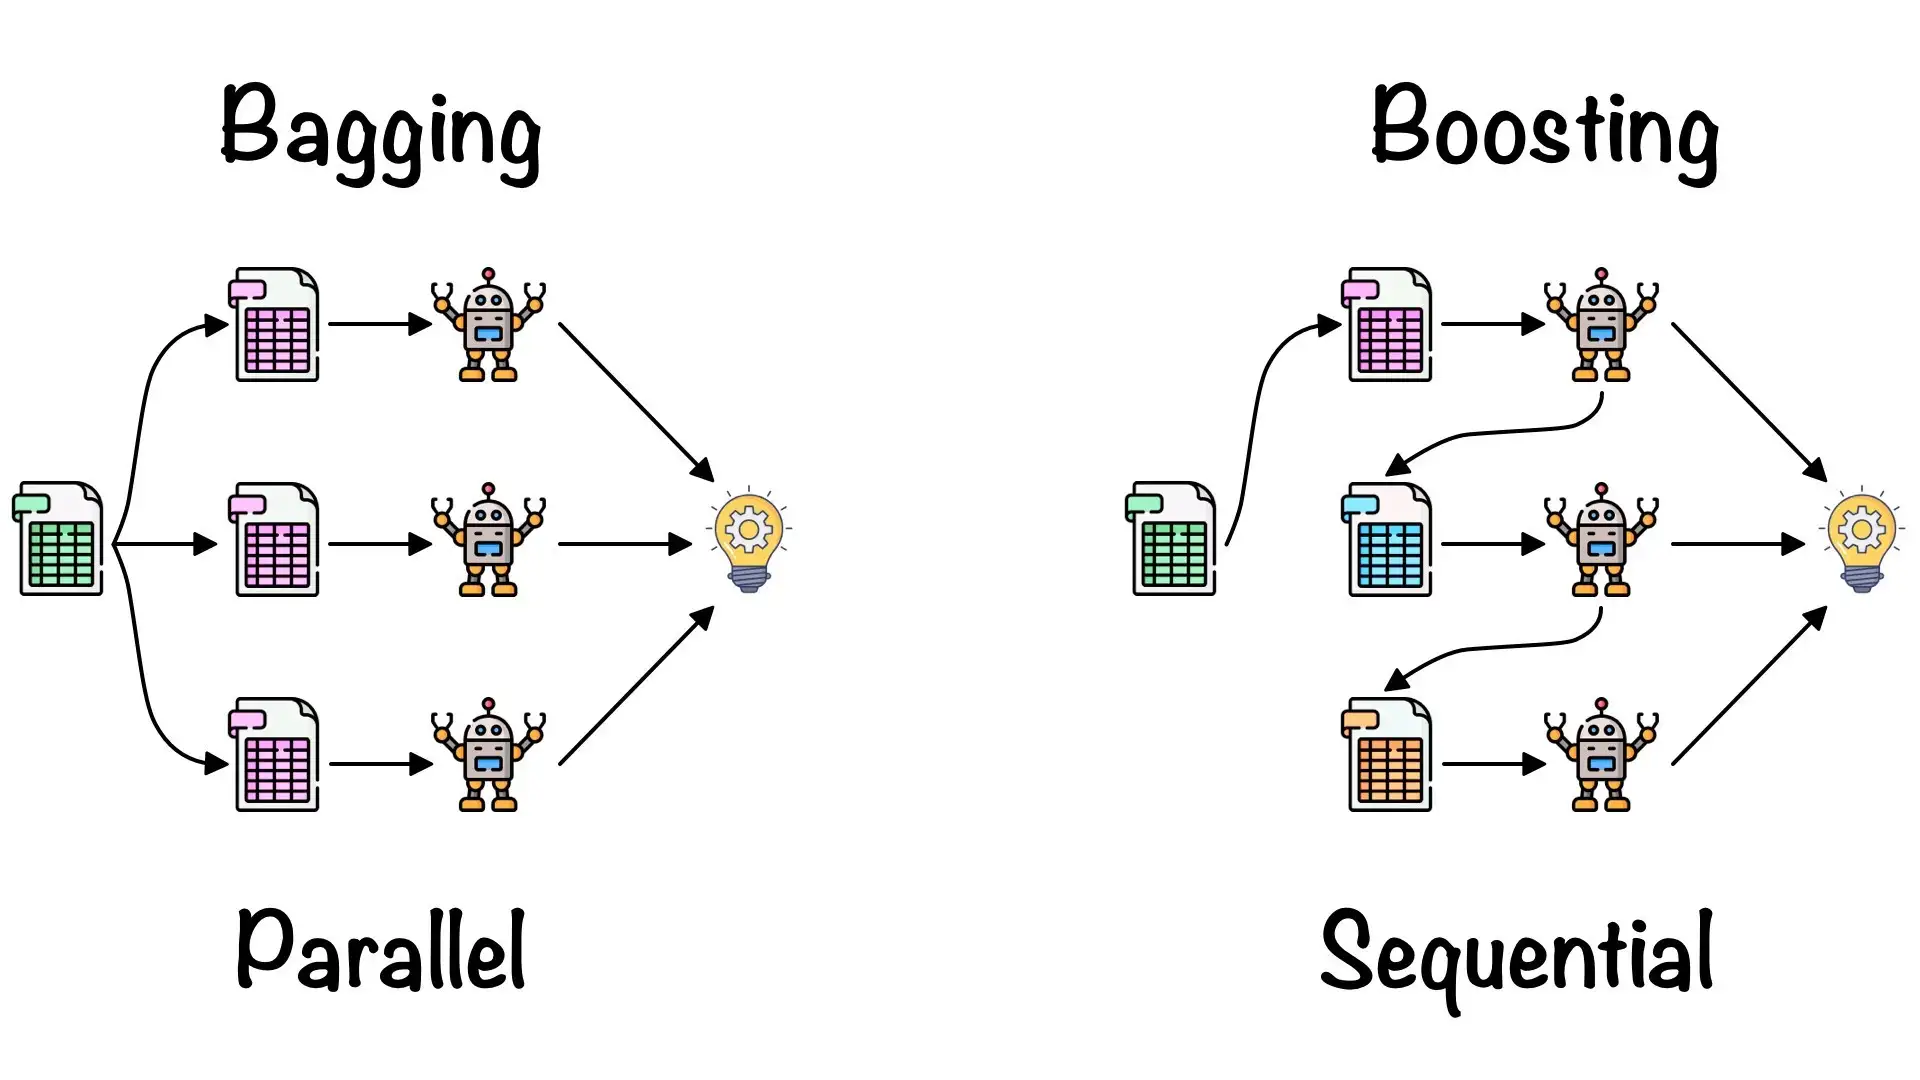

# 각 앙상블 모델 어떨 때 사용?
- 랜덤포레스트 -> 빠르고 간단하고 성능 무난
- XGB -> 최고 성능을 목표로 한다면
- Light GBM -> 대용량 데이터
- Catboost -> 범주형 컬럼이 많을 때

# Random Forest (분류)

## 기본 버젼

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) 데이터 로드
data = load_breast_cancer()
X = data.data
y = data.target

# 2) train / temp 분리
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# 3) valid / test 분리
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Test :", X_test.shape)

# 4) 모델 생성
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

# 5) 학습
model.fit(X_train, y_train)

# 6) 검증 성능 확인
valid_pred = model.predict(X_valid)
valid_acc = accuracy_score(y_valid, valid_pred)

print("\nValidation Accuracy:", valid_acc)
print(classification_report(y_valid, valid_pred))

# 7) 테스트 성능 확인
test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("\nTest Accuracy:", test_acc)
print(classification_report(y_test, test_pred))

Train: (341, 30)
Valid: (114, 30)
Test : (114, 30)

Validation Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Test Accuracy: 0.9122807017543859
              precision    recall  f1-score   support

           0       0.87      0.91      0.89        43
           1       0.94      0.92      0.93        71

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



## GridSearch + Pipeline 사용 버젼

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) 데이터 로드
data = load_breast_cancer()
X = data.data
y = data.target

# 2) train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3) Pipeline 구성
pipeline = Pipeline([
    ("rf", RandomForestClassifier(random_state=42))
])

# 4) 하이퍼파라미터 후보
param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [None, 5, 10],
    "rf__min_samples_split": [2, 5]
}

# 5) GridSearch
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# 6) 학습 (train 데이터에서 CV로 validation 수행)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

# 7) 최종 test 평가
best_model = grid.best_estimator_
test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("\nTest Accuracy:", test_acc)
print(classification_report(y_test, test_pred))

Best Parameters: {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 200}
Best CV Score: 0.9604395604395606

Test Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



# Random Forest (회귀)

## 기본 버젼

In [ ]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1) 데이터 로드
data = load_diabetes()
X = data.data
y = data.target

# 2) train / temp 분리
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# 3) valid / test 분리
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)
print("Test :", X_test.shape)

# 4) 모델 생성
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# 5) 학습
model.fit(X_train, y_train)

# 6) valid 평가
valid_pred = model.predict(X_valid)
valid_r2 = r2_score(y_valid, valid_pred)
valid_mae = mean_absolute_error(y_valid, valid_pred)
valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))

print("R2  :", valid_r2)
print("MAE :", valid_mae)
print("RMSE:", valid_rmse)

# 7) test 평가
test_pred = model.predict(X_test)
test_r2 = r2_score(y_test, test_pred)
test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("R2  :", test_r2)
print("MAE :", test_mae)
print("RMSE:", test_rmse)

Train: (265, 10)
Valid: (88, 10)
Test : (89, 10)
R2  : 0.5040685769914828
MAE : 42.13742424242424
RMSE: 53.46965123820571
R2  : 0.47773308430008243
MAE : 44.533183520599245
RMSE: 54.96417430861865


# 랜덤 포레스트 핵심 하이퍼 파라미터

- n_estimators	트리 개수
  - 많을수록 안정적 (속도 ↓)
- max_depth	트리 최대 깊이
  - 깊으면 과적합
- min_samples_split	노드 분할 최소 샘플 수
  - 크면 보수적 모델
- min_samples_leaf	리프 최소 샘플 수
  - 크면 부드러운 모델
- max_features	분할 시 사용할 feature 수
  - 작으면 다양성 ↑

# 실무 랜덤포레스트 하이퍼 파라미터 조정

- 과적합 줄이고 싶다

  - max_depth ↓

  - min_samples_leaf ↑

  - max_features ↓

- 성능이 약하다

  - n_estimators ↑

  - max_depth ↑

## GridSearch + Pipeline 사용 버젼


### 아래 코드 조금 오래 걸림

In [ ]:

import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1) 데이터 로드
data = load_diabetes()
X = data.data
y = data.target

# 2) train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3) Pipeline 구성
pipe = Pipeline([
    ("scaler", StandardScaler()), # 로지스틱 회귀랑 트리기반모델 다 사용해보고 싶다 -> 데이터를 어떻게? -> 둘다 스케일링 써서 비교
    ("rf", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# 4) 파라미터 그리드
param_grid = {
    "rf__n_estimators": [200, 500],
    "rf__max_depth": [None, 5, 10],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 2, 4]
}

# 5) GridSearchCV
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="r2",   # 회귀 대표 지표
    n_jobs=-1
)

# 6) 학습
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV R2 :", grid.best_score_)

# 7) 최종 test 평가
best_model = grid.best_estimator_
test_pred = best_model.predict(X_test)

test_r2 = r2_score(y_test, test_pred)
test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("R2  :", test_r2)
print("MAE :", test_mae)
print("RMSE:", test_rmse)

Best Params: {'rf__max_depth': 5, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 500}
Best CV R2 : 0.4125394000151353
R2  : 0.45891278917527567
MAE : 43.47811061917257
RMSE: 53.54215303974042
